# 01 — Data Understanding

This notebook confirms the real dataset schema, checks the target distribution, and documents
the leakage risk around `duration` before any modeling happens.

**Why this matters:** a realistic bank marketing model can only use information available before
a customer is contacted. `duration` — how long the call lasted — is only known *after* the call,
so a model trained on it would look strong in evaluation but couldn't be used for its actual
purpose: deciding who to call.

**Goals:** confirm the schema, check class imbalance, review data quality issues, and identify
leakage-prone variables.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Walk up from the current directory until we find the project root (the folder
# containing src/). This works whether Jupyter's cwd is the repo root or notebooks/.
project_root = Path.cwd()
while not (project_root / 'src').exists() and project_root != project_root.parent:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_loader import find_dataset_path, load_bank_data
from src.config import LEAKAGE_COLUMNS, TARGET

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
print('Project root:', project_root)

Project root: /Users/a.3zz/NTI Project/bank-marketing-ai


In [2]:
try:
    dataset_path = find_dataset_path()
    print('Found dataset at', dataset_path)
except FileNotFoundError as exc:
    print(exc)
    print('Run: python -m src.download_data')
    raise

Found dataset at /Users/a.3zz/NTI Project/bank-marketing-ai/data/bank_marketing.csv


In [3]:
raw_df = load_bank_data(dataset_path)
print('Shape:', raw_df.shape)
raw_df.head()

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
raw_df.dtypes

age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

## Target distribution and class imbalance

y
no     36548
yes     4640
Name: count, dtype: int64
Positive rate: 0.1127


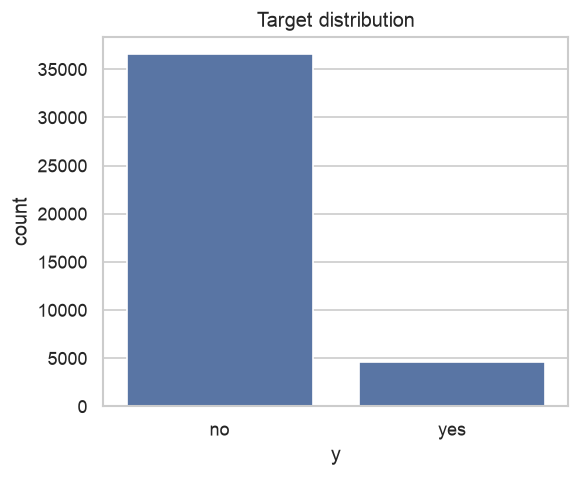

In [5]:
target_counts = raw_df[TARGET].value_counts(dropna=False)
print(target_counts)
print(f"Positive rate: {target_counts.get('yes', 0) / len(raw_df):.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=raw_df, x=TARGET, order=['no', 'yes'], ax=ax)
ax.set_title('Target distribution')
plt.show()

Only about 11% of customers subscribed. Accuracy alone is a poor metric here — a model that always predicts 'no' would already be ~89% accurate while being useless for targeting.

## Data quality: duplicates and missing values

In [6]:
print('Exact duplicate rows:', raw_df.duplicated().sum())
print('Duplicate rows once `duration` is ignored:', raw_df.drop(columns=['duration']).duplicated().sum())
print()
print('Missing values per column:')
print(raw_df.isna().sum().sum(), 'total (this dataset uses the string \'unknown\' instead of NaN)')
for col in raw_df.select_dtypes(exclude='number'):  # works the same on pandas 2's object dtype and pandas 3's str dtype
    n_unknown = (raw_df[col] == 'unknown').sum()
    if n_unknown:
        print(f'  {col:12} unknown = {n_unknown:,} ({n_unknown / len(raw_df):.1%})')

Exact duplicate rows: 12
Duplicate rows once `duration` is ignored: 1784

Missing values per column:
0 total (this dataset uses the string 'unknown' instead of NaN)
  job          unknown = 330 (0.8%)
  marital      unknown = 80 (0.2%)
  education    unknown = 1,731 (4.2%)
  default      unknown = 8,597 (20.9%)
  housing      unknown = 990 (2.4%)
  loan         unknown = 990 (2.4%)


There are only 12 exact duplicate rows, but 1,784 rows become duplicates once `duration` is dropped — i.e. many customers were called more than once with an identical profile. Those are legitimate repeat records, not data-entry errors, so cleaning drops duplicates on the *full* row (including `duration`) rather than after removing it — see `src/preprocessing.py`.

## Why `duration` is a leakage feature

In [7]:
for col in LEAKAGE_COLUMNS:
    print(f'{col}: excluded from all production features (see src/config.LEAKAGE_COLUMNS)')

print()
print(raw_df.groupby(pd.cut(raw_df['duration'], [0, 60, 180, 600, raw_df['duration'].max()]))[TARGET]
      .apply(lambda s: (s == 'yes').mean()))

duration: excluded from all production features (see src/config.LEAKAGE_COLUMNS)

duration
(0, 60]        0.000234
(60, 180]      0.034290
(180, 600]     0.140549
(600, 4918]    0.486143
Name: y, dtype: float64


`duration` reflects how long the call lasted, which is only known after the customer has already been contacted. Longer calls convert far more often (the table above), which makes intuitive sense — but a model can't act on it, since the decision to prioritize this customer has to be made *before* any call happens. Including it teaches the model a pattern it can never use in production. Notebook 03 quantifies exactly how much better (and how misleading) a model that cheats with `duration` looks.

## Next step

Notebook 02 moves into EDA: which customer and campaign factors are actually associated with a higher response rate, using only information available before contact.